# PROJET CLASSIFICATION DE SENTIMENTS

## Chargement des données d'entrainement

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import codecs
import re
import os.path

In [2]:
def load_movies(path2data): # 1 classe par répertoire
    alltxts = [] # init vide
    labs = []
    cpt = 0
    for cl in os.listdir(path2data): # parcours des fichiers d'un répertoire
        print("Ouverture du dossier",cl,"->labellisé par ",cpt)
        for f in os.listdir(path2data+cl):
            txt = open(path2data+cl+'/'+f).read()
            alltxts.append(txt)
            labs.append(cpt)
        cpt+=1 # chg répertoire = cht classe

    return alltxts,labs
#0 le commentaire est positif, 1 le commentaire est négatif

In [3]:
path = "./movies1000/"

alltxts,alllabs = load_movies(path)

Ouverture du dossier pos ->labellisé par  0
Ouverture du dossier neg ->labellisé par  1


## Chargement des données mystère à labelliser

In [4]:
def load_pres_test(fname):
    with open(fname, 'r',encoding='utf-8') as f:
        txt = f.read()
    alltxts = txt.split("\n")
    alltxts_test = [a.replace("<br /><br />","") for a in alltxts]
    return alltxts_test

fname = "./ProjetTestSet/testSentiment.txt"
alltxts_test = load_pres_test(fname)
alltxts_test = alltxts_test[:-1]
print(len(alltxts_test))
print(alltxts_test[-3:])

25000
["I saw 'Descent' last night at the Stockholm Film Festival and it was one huge disappointment. Disappointment because the storyline was potentially powerful, the prospect of seeing Rosario Dawson in a smaller intimate movie was exciting and, being a fan (sounds pervy, I'm not!) of 'rape/revenge' flicks of the 70's, I was needless to say very curious to check this movie out. My conclusion: let's stick to the classics! Yes, the storyline has potential but the dialogs are flat, the actors unconvincing. Even Dawson is empty. Some would say that it's a right depiction of the college world in the US, that the emptiness of the characters serve a purpose and all that jazz but it just makes the whole movie unsubstantial. Just like the scene where Dawson gets raped: it seriously lacks intensity! I wasn't expecting anything 'Irreversible'-style but still, aren't we suppose to feel compassion for her? I didn't. Not for a minute, she was so lame all the way ;-) And I read that the photograph

### BAG OF WORDS SIMPLE - SOUMISSION 3

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Diviser les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(alltxts, alllabs, test_size=0.2, random_state=42)

# Créer le Bag of Words
vectorizer = CountVectorizer(stop_words='english', max_features=8000)
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

# Entraîner le classifieur (Régression Logistique)
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_bow, y_train)

# Prédire sur l'ensemble de test
y_pred = classifier.predict(X_test_bow)

# Évaluer les performances
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Exemple de prédiction sur un nouveau commentaire
new_comment = ["This movie was absolutely terrible and boring."]
new_comment_bow = vectorizer.transform(new_comment)
prediction = classifier.predict(new_comment_bow)
print("\nPrédiction pour le nouveau commentaire:", "Négatif" if prediction[0] == 1 else "Positif")

Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85       199
           1       0.84      0.87      0.85       201

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400


Prédiction pour le nouveau commentaire: Négatif


In [12]:
import pandas as pd

#Vectoriser les données de test avec le même vectorizer que pour l'entraînement

X_test_tfidf = vectorizer.transform(alltxts_test)

#Prédire les labels pour les données de test
y_test_pred = classifier.predict(X_test_tfidf)

#Convertir les labels en 'N' (négatif) ou 'P' (positif)
y_test_labels = ['N' if pred == 1 else 'P' for pred in y_test_pred]

#Créer un DataFrame et sauvegarder en CSV
submission = pd.DataFrame({'Label': y_test_labels})
submission.to_csv('./SUBMISSIONS_MOVIES/submission-movie-#.csv', index=False, header=False)

print("Fichier de soumission généré : submission-movie-#.csv")

Fichier de soumission généré : submission-movie-#.csv


### Avec TF-IDF SOUMISSION 2

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_tfidf, y_train)


y_pred = classifier.predict(X_test_tfidf)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Rapport:\n", classification_report(y_test, y_pred))




Accuracy: 0.8275

Classification Rapport:
               precision    recall  f1-score   support

           0       0.82      0.83      0.83       199
           1       0.83      0.82      0.83       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



In [10]:
import pandas as pd


# 2. Vectoriser les données de test avec le même vectorizer que pour l'entraînement

X_test_tfidf = vectorizer.transform(alltxts_test)

# 3. Prédire les labels pour les données de test
y_test_pred = classifier.predict(X_test_tfidf)

# 4. Convertir les labels en 'N' (négatif) ou 'P' (positif)
y_test_labels = ['N' if pred == 1 else 'P' for pred in y_test_pred]

# 5. Créer un DataFrame et sauvegarder en CSV
submission = pd.DataFrame({'Label': y_test_labels})
submission.to_csv('./SUBMISSIONS_MOVIES/submission-movie-#.csv', index=False, header=False)

print("Fichier de soumission généré : submission-movie-#.csv")

Fichier de soumission généré : submission-movie-#.csv


### Avec stemming

In [14]:

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


def stem_text(text):
    stemmer = PorterStemmer()
    words = word_tokenize(text)
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

#Racinisation des données : 
alltxts_racine = [stem_text(alltxt) for alltxt in alltxts]

[nltk_data] Downloading package punkt to
[nltk_data]     /home/nilsbarrellon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/nilsbarrellon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [15]:
X_train, X_test, y_train, y_test = train_test_split(alltxts_racine, alllabs, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_tfidf, y_train)

y_pred = classifier.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Rapport:\n", classification_report(y_test, y_pred))



Accuracy: 0.83

Classification Rapport:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       199
           1       0.83      0.83      0.83       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



### Avec lemmatisation

In [16]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word, pos='v') for word in words]  # pos='v' pour les verbes
    return ' '.join(lemmatized_words)

alltxts_lemmatized = [lemmatize_text(alltxt) for alltxt in alltxts]

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nilsbarrellon/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/nilsbarrellon/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [17]:
X_train, X_test, y_train, y_test = train_test_split(alltxts_lemmatized, alllabs, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_tfidf, y_train)

y_pred = classifier.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Rapport:\n", classification_report(y_test, y_pred))



Accuracy: 0.8375

Classification Rapport:
               precision    recall  f1-score   support

           0       0.84      0.83      0.84       199
           1       0.83      0.85      0.84       201

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



### avec n-grammes, racinisation et modele SVC - SOUMISSION 1

In [18]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(alltxts_lemmatized, alllabs, test_size=0.2, random_state=42)

vectorizerNgrammesSVC = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,3) 
)
X_train_tfidf = vectorizerNgrammesSVC.fit_transform(X_train)
X_test_tfidf = vectorizerNgrammesSVC.transform(X_test)

classifierSVC = SVC(kernel='linear', C=1.0, random_state=42)
classifierSVC.fit(X_train_tfidf, y_train)
y_pred = classifierSVC.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Rapport:\n", classification_report(y_test, y_pred))





Accuracy: 0.835

Classification Rapport:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83       199
           1       0.83      0.84      0.84       201

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



In [19]:
import pandas as pd

alltxts_test_lemmatized = [lemmatize_text(text) for text in alltxts_test]

# 2. Vectoriser les données de test avec le même vectorizer que pour l'entraînement

X_test_tfidf = vectorizerNgrammesSVC.transform(alltxts_test_lemmatized)

# 3. Prédire les labels pour les données de test
y_test_pred = classifierSVC.predict(X_test_tfidf)

# 4. Convertir les labels en 'N' (négatif) ou 'P' (positif)
y_test_labels = ['N' if pred == 1 else 'P' for pred in y_test_pred]

# 5. Créer un DataFrame et sauvegarder en CSV
submission = pd.DataFrame({'Label': y_test_labels})
submission.to_csv('./SUBMISSIONS_MOVIES/submission-movie-#.csv', index=False, header=False)

print("Fichier de soumission généré : submission-movie-#.csv")

Fichier de soumission généré : submission-movie-#.csv


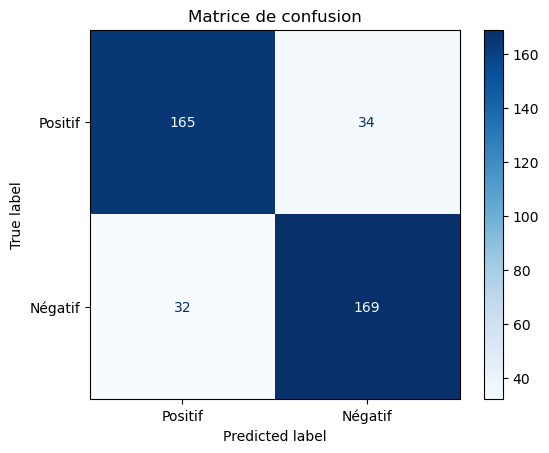


Exemples de commentaires mal classés :

Commentaire: kevin smith be like a big kid . his humor be that of a sophisticate juvenile 's . he grow up idolize...
Vrai label: Positif, Prédit: Négatif

Commentaire: anastasia contain something that have be lack from all of the recent disney release . . . ( especial...
Vrai label: Positif, Prédit: Négatif

Commentaire: ok , let 's get one thing straight right away : maximum risk be no battleship potemkin ( although it...
Vrai label: Positif, Prédit: Négatif

Commentaire: in 1987 the stock market crash , and oliver stone 's wall street be release to critical acclaim and ...
Vrai label: Positif, Prédit: Négatif

Commentaire: `` well this be not mission : difficult , mr . hunt , it 's mission : impossible . difficult should ...
Vrai label: Positif, Prédit: Négatif

Commentaire: `` the beach `` be a structurally confuse film that i can only describe have have multiple personali...
Vrai label: Négatif, Prédit: Positif

Commentaire: susan granger 's

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positif", "Négatif"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.show()

# Extraire les commentaires mal classés
#errors = X_test[y_pred != y_test]
errors = [X_test[i] for i in range(len(X_test)) if y_pred[i]!=y_test[i]]
#true_labels = y_test[y_pred != y_test]
true_labels = [y_test[i] for i in range(len(y_test)) if y_pred[i]!=y_test[i]]
#predicted_labels = y_pred[y_pred != y_test]
predicted_labels = [y_pred[i] for i in range(len(y_pred)) if y_pred[i]!=y_test[i]]
print("\nExemples de commentaires mal classés :")
for comment, true, pred in zip(errors[:10], true_labels[:10], predicted_labels[:10]):
    # Si X_test est une Series pandas ou un tableau NumPy de strings
    if hasattr(comment, 'shape') or isinstance(comment, np.ndarray):
        comment_text = " ".join(vectorizer.inverse_transform(comment.reshape(1, -1))[0]).strip()
    else:
        comment_text = str(comment)[:100]  # Tronquer pour l'affichage
    print(f"\nCommentaire: {comment_text}...")
    print(f"Vrai label: {'Négatif' if true == 1 else 'Positif'}, Prédit: {'Négatif' if pred == 1 else 'Positif'}")


### TF-IDF et N-GRAMMES - SOUMISSION 4 et 6 (restriction du vocabulaire)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer4 = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_features=5000)
X_train_tfidf = vectorizer4.fit_transform(X_train)
X_test_tfidf = vectorizer4.transform(X_test)

classifier4 = LogisticRegression(max_iter=2000)
classifier4.fit(X_train_tfidf, y_train)


y_pred = classifier4.predict(X_test_tfidf)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Rapport:\n", classification_report(y_test, y_pred))



NameError: name 'X_train' is not defined

In [18]:
import pandas as pd

X_test_tfidf = vectorizer4.transform(alltxts_test)

# Prédire les labels pour les données de test
y_test_pred = classifier4.predict(X_test_tfidf)

# Convertir les labels en 'N' (négatif) ou 'P' (positif)
y_test_labels = ['N' if pred == 1 else 'P' for pred in y_test_pred]

# Créer un DataFrame et sauvegarder en CSV
submission = pd.DataFrame({'Label': y_test_labels})
submission.to_csv('./SUBMISSIONS_MOVIES/submission-movie-#.csv', index=False, header=False)

print("Fichier de soumission généré : submission-movie-#.csv")

Fichier de soumission généré : submission-movie-#.csv


## SOUMISSION 5 : BAG Binaire

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(alltxts, alllabs, test_size=0.2, random_state=42)
vectorizer5 = CountVectorizer(stop_words='english',binary=True)
X_train5 = vectorizer5.fit_transform(X_train)
X_test5 = vectorizer5.transform(X_test)

classifier5 = LogisticRegression(max_iter=2000)
classifier5.fit(X_train5, y_train)


y_pred5 = classifier5.predict(X_test5)


print("Accuracy:", accuracy_score(y_test, y_pred5))
print("\nRapport:\n", classification_report(y_test, y_pred5))

Accuracy: 0.8525

Rapport:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       199
           1       0.85      0.86      0.85       201

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [12]:
import pandas as pd

X_test_5 = vectorizer5.transform(alltxts_test)

# 3. Prédire les labels pour les données de test
y_test_pred5 = classifier5.predict(X_test_5)

# 4. Convertir les labels en 'N' (négatif) ou 'P' (positif)
y_test_labels = ['N' if pred == 1 else 'P' for pred in y_test_pred5]

# 5. Créer un DataFrame et sauvegarder en CSV
submission = pd.DataFrame({'Label': y_test_labels})
submission.to_csv('./SUBMISSIONS_MOVIES/submission-movie-#.csv', index=False, header=False)

print("Fichier de soumission généré : submission-movie-#.csv")

Fichier de soumission généré : submission-movie-#.csv
